##### Fund Performance Analysis

In [143]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Loading datasets
nav = pd.read_csv("../data/processed/cleaned_nav_history.csv")
perf = pd.read_csv("../data/processed/cleaned_scheme_performance.csv")
benchmark = pd.read_csv("../data/processed/cleaned_benchmark_indices.csv")
fund_master = pd.read_csv("../data/processed/cleaned_fund_master.csv")

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

### Daily Returns

In [144]:
nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

returns = nav.dropna(subset=["daily_return"])

print(returns["daily_return"].describe())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


### Distribution Validation

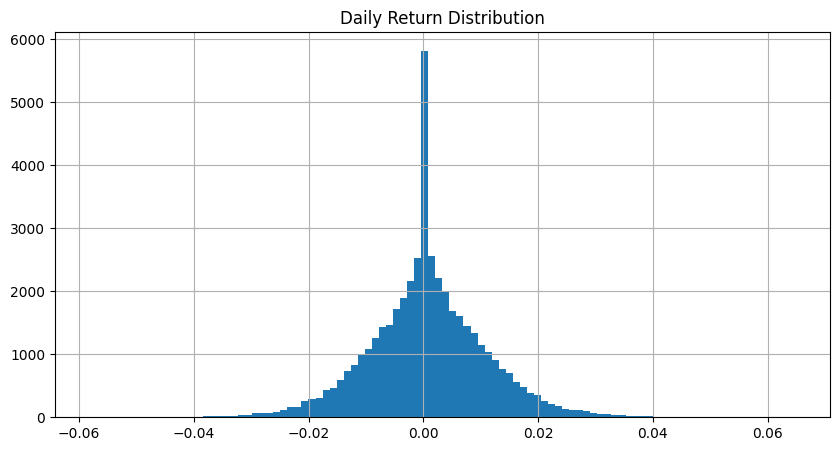

In [145]:
plt.figure(figsize=(10,5))
returns["daily_return"].hist(bins=100)
plt.title("Daily Return Distribution")
plt.show()

  ### CAGR for (1Y / 3Y / 5Y)

In [146]:
def calculate_cagr(df, years):

    end_date = df["date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    temp = df[df["date"] >= start_date]

    results = []

    for code, g in temp.groupby("amfi_code"):

        g = g.sort_values("date")

        if len(g) < 2:
            continue

        start_nav = g.iloc[0]["nav"]
        end_nav = g.iloc[-1]["nav"]

        cagr = (end_nav/start_nav)**(1/years)-1

        results.append([code,cagr])

    return pd.DataFrame(results,
                        columns=["amfi_code",f"CAGR_{years}Y"])

In [147]:
cagr1 = calculate_cagr(nav,1)
cagr3 = calculate_cagr(nav,3)
cagr5 = calculate_cagr(nav,5)

cagr_table = cagr1.merge(cagr3,on="amfi_code")
cagr_table = cagr_table.merge(cagr5,on="amfi_code")

cagr_table.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


### Sharpe Ratio

In [148]:
# Risk-free rate (annual)
RF = 0.065

# Convert to daily risk-free rate
daily_rf = RF / 252

sharpe_list = []

for code, g in returns.groupby("amfi_code"):

    mean_return = g["daily_return"].mean()
    volatility = g["daily_return"].std()

    if volatility == 0 or pd.isna(volatility):
        sharpe = np.nan
    else:
        sharpe = ((mean_return - daily_rf) / volatility) * np.sqrt(252)

    sharpe_list.append({
        "amfi_code": code,
        "mean_daily_return": mean_return,
        "volatility": volatility,
        "Sharpe_Ratio": sharpe
    })

# Create dataframe
sharpe_df = pd.DataFrame(sharpe_list)

# Rank funds (highest Sharpe = Rank 1)
sharpe_df["Sharpe_Rank"] = sharpe_df["Sharpe_Ratio"].rank(
    ascending=False,
    method="dense"
)

# Sort by rank
sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

# Display top funds
print(sharpe_df.head(10))

    amfi_code  mean_daily_return  volatility  Sharpe_Ratio  Sharpe_Rank
34     148567           0.001074    0.008941      1.448291          1.0
30     120843           0.001082    0.010008      1.306744          2.0
36     148569           0.001124    0.011134      1.234930          3.0
19     119551           0.000917    0.008656      1.208267          4.0
25     120505           0.001161    0.012152      1.180101          5.0
38     149323           0.001055    0.011179      1.132122          6.0
2      100033           0.001080    0.011929      1.093699          7.0
9      118632           0.000865    0.008913      1.081659          8.0
3      101206           0.000852    0.009177      1.027213          9.0
24     120504           0.000843    0.009048      1.026524         10.0


In [149]:
# Save deliverable
sharpe_df.to_csv("../data/processed/sharpe_ratio_ranking.csv", index=False)

print("Saved: sharpe_ratio_ranking.csv")

Saved: sharpe_ratio_ranking.csv


### Sortino Ratio Ranking for All 40 Funds

In [150]:
RF = 0.065
daily_rf = RF / 252

sortino_list = []

for code, g in returns.groupby("amfi_code"):

    mean_return = g["daily_return"].mean()

    # Only negative return days
    downside_returns = g.loc[
        g["daily_return"] < 0,
        "daily_return"
    ]

    downside_std = downside_returns.std()

    if downside_std == 0 or pd.isna(downside_std):
        sortino = np.nan
    else:
        sortino = (
            (mean_return - daily_rf)
            / downside_std
        ) * np.sqrt(252)

    sortino_list.append({
        "amfi_code": code,
        "mean_daily_return": mean_return,
        "downside_std": downside_std,
        "Sortino_Ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_list)

# Rank funds
sortino_df["Sortino_Rank"] = (
    sortino_df["Sortino_Ratio"]
    .rank(
        ascending=False,
        method="dense"
    )
)

sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
)

print(sortino_df.head(10))

    amfi_code  mean_daily_return  downside_std  Sortino_Ratio  Sortino_Rank
34     148567           0.001074      0.005428       2.385644           1.0
30     120843           0.001082      0.005531       2.364320           2.0
36     148569           0.001124      0.006404       2.146914           3.0
19     119551           0.000917      0.004887       2.140267           4.0
25     120505           0.001161      0.007067       2.029353           5.0
38     149323           0.001055      0.006750       1.875101           6.0
9      118632           0.000865      0.005211       1.850133           7.0
2      100033           0.001080      0.007133       1.829134           8.0
24     120504           0.000843      0.005145       1.805294           9.0
3      101206           0.000852      0.005238       1.799563          10.0


### Alpha and Beta Using OLS Regression

##### Compute Nifty 100 Daily Returns

In [151]:
# Convert date column

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

# Filter NIFTY100 benchmark

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

# Sort by date

nifty100 = nifty100.sort_values(
    "date"
)

# Calculate benchmark returns

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

# Keep required columns

nifty100 = nifty100[
    ["date", "benchmark_return"]
].dropna()

print(nifty100.head())

           date  benchmark_return
3451 2022-01-04         -0.013540
3452 2022-01-05          0.004003
3453 2022-01-06         -0.002935
3454 2022-01-07          0.006150
3455 2022-01-10         -0.008351


##### Alpha-Beta Calculation

In [152]:
alpha_beta_list = []

for code, g in returns.groupby("amfi_code"):

    # Merge fund returns with benchmark returns

    merged = pd.merge(
        g[["date", "daily_return"]],
        nifty100,
        on="date",
        how="inner"
    ).dropna()

    # Skip insufficient observations

    if len(merged) < 30:
        continue

    # OLS Regression

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta_list.append([
        code,
        intercept * 252,   # Annualized Alpha
        slope,             # Beta
        r_value**2,
        p_value,
        len(merged)
    ])

In [153]:
alpha_beta_df = pd.DataFrame(
    alpha_beta_list,
    columns=[
        "amfi_code",
        "Alpha",
        "Beta",
        "R_Squared",
        "P_Value",
        "Observations"
    ]
)

print(alpha_beta_df.head())

   amfi_code     Alpha      Beta  R_Squared   P_Value  Observations
0     100016  0.037476 -0.058268   0.002665  0.080264          1149
1     100025  0.042818  0.001158   0.000015  0.897012          1149
2     100033  0.271954  0.005104   0.000012  0.906369          1149
3     101206  0.213998  0.021086   0.000348  0.527551          1149
4     101207  0.108971 -0.065289   0.001064  0.269234          1149


##### Rank Funds by Alpha

In [154]:
alpha_beta_df["Alpha_Rank"] = (
    alpha_beta_df["Alpha"]
    .rank(
        ascending=False,
        method="dense"
    )
)

alpha_beta_df = alpha_beta_df.sort_values(
    "Alpha",
    ascending=False
)

print(alpha_beta_df.head(10))

    amfi_code     Alpha      Beta     R_Squared   P_Value  Observations  \
21     119598  0.303370 -0.023196  1.414258e-04  0.687179          1149   
39     149324  0.300579  0.011455  3.532991e-05  0.840494          1149   
25     120505  0.292636  0.000549  1.345534e-07  0.990090          1149   
36     148569  0.282704  0.018134  1.748889e-04  0.654295          1149   
30     120843  0.273305 -0.022830  3.430543e-04  0.530528          1149   
2      100033  0.271954  0.005104  1.206652e-05  0.906369          1149   
34     148567  0.269838  0.023684  4.625437e-04  0.466427          1149   
38     149323  0.265986 -0.002523  3.357978e-06  0.950525          1149   
16     119094  0.260767 -0.066265  1.936879e-03  0.135988          1149   
19     119551  0.232010 -0.031751  8.869789e-04  0.313143          1149   

    Alpha_Rank  
21         1.0  
39         2.0  
25         3.0  
36         4.0  
30         5.0  
2          6.0  
34         7.0  
38         8.0  
16         9.0  
19  

In [155]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully")

alpha_beta.csv saved successfully


### Maximum Drawdown (MDD)

In [156]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

drawdown_results = []

In [157]:
for code, g in nav.groupby("amfi_code"):

    g = g.sort_values("date").copy()

    # Running peak NAV
    g["running_max"] = g["nav"].cummax()

    # Drawdown
    g["drawdown"] = (
        g["nav"] / g["running_max"]
    ) - 1

    # Worst drawdown value
    max_dd = g["drawdown"].min()

    # Drawdown trough date
    trough_idx = g["drawdown"].idxmin()

    trough_date = g.loc[
        trough_idx,
        "date"
    ]

    drawdown_results.append([
        code,
        max_dd,
        trough_date
    ])

##### Create Maximum Drawdown Table

In [158]:
drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "Max_Drawdown",
        "Worst_Drawdown_Date"
    ]
)

drawdown_df = drawdown_df.sort_values(
    "Max_Drawdown"
)

print(drawdown_df.head(10))

    amfi_code  Max_Drawdown Worst_Drawdown_Date
22     119599     -0.525742          2025-10-28
17     119095     -0.516778          2026-05-11
4      101207     -0.354469          2026-05-11
39     149324     -0.311719          2025-01-03
21     119598     -0.287060          2025-05-14
7      102886     -0.280011          2026-04-27
0      100016     -0.247344          2022-09-15
29     120842     -0.240035          2024-10-17
11     118634     -0.233449          2026-02-20
15     119093     -0.217514          2023-05-22


In [159]:
drawdown_ranges = []

for code, g in nav.groupby("amfi_code"):

    g = g.sort_values("date").copy()

    g["running_max"] = g["nav"].cummax()

    g["drawdown"] = (
        g["nav"] / g["running_max"]
    ) - 1

    trough_idx = g["drawdown"].idxmin()

    trough_date = g.loc[
        trough_idx,
        "date"
    ]

    peak_nav = g.loc[
        trough_idx,
        "running_max"
    ]

    peak_date = g[
        g["nav"] == peak_nav
    ]["date"].iloc[0]

    drawdown_ranges.append([
        code,
        peak_date,
        trough_date,
        g["drawdown"].min()
    ])

##### Date Range Table

In [160]:
drawdown_range_df = pd.DataFrame(
    drawdown_ranges,
    columns=[
        "amfi_code",
        "Peak_Date",
        "Trough_Date",
        "Max_Drawdown"
    ]
)

print(drawdown_range_df.head())

   amfi_code  Peak_Date Trough_Date  Max_Drawdown
0     100016 2022-03-30  2022-09-15     -0.247344
1     100025 2023-05-23  2023-07-28     -0.043083
2     100033 2022-03-11  2022-05-12     -0.162172
3     101206 2023-04-24  2023-07-05     -0.112916
4     101207 2024-11-21  2026-05-11     -0.354469


### Fund Scorecard (0–100)

##### CAGR Rank

In [161]:
cagr_rank = cagr_table[
    ["amfi_code", "CAGR_3Y"]
].copy()

cagr_rank["return_rank"] = (
    cagr_rank["CAGR_3Y"]
    .rank(
        ascending=False,
        method="dense"
    )
)

Sharpe Rank

In [162]:
sharpe_rank = sharpe_df[
    ["amfi_code", "Sharpe_Ratio"]
].copy()

sharpe_rank["sharpe_rank"] = (
    sharpe_rank["Sharpe_Ratio"]
    .rank(
        ascending=False,
        method="dense"
    )
)

Alpha Rank

In [163]:
alpha_rank = alpha_beta_df[
    ["amfi_code", "Alpha"]
].copy()

alpha_rank["alpha_rank"] = (
    alpha_rank["Alpha"]
    .rank(
        ascending=False,
        method="dense"
    )
)

Expense Ratio Rank

In [164]:
expense_rank = fund_master[
    ["amfi_code", "expense_ratio_pct"]
].copy()

expense_rank["expense_rank"] = (
    expense_rank["expense_ratio_pct"]
    .rank(
        ascending=True,
        method="dense"
    )
)

Max Drawdown Rank

In [165]:
dd_rank = drawdown_df[
    ["amfi_code", "Max_Drawdown"]
].copy()

dd_rank["dd_rank"] = (
    dd_rank["Max_Drawdown"]
    .rank(
        ascending=False,
        method="dense"
    )
)

Merge Everything

In [166]:
scorecard = (
    cagr_rank
    .merge(
        sharpe_rank[
            ["amfi_code", "sharpe_rank"]
        ],
        on="amfi_code"
    )
    .merge(
        alpha_rank[
            ["amfi_code", "alpha_rank"]
        ],
        on="amfi_code"
    )
    .merge(
        expense_rank[
            ["amfi_code", "expense_rank"]
        ],
        on="amfi_code"
    )
    .merge(
        dd_rank[
            ["amfi_code", "dd_rank"]
        ],
        on="amfi_code"
    )
)

Calculate Weighted Score

In [167]:
scorecard["raw_score"] = (

      0.30 * scorecard["return_rank"]

    + 0.25 * scorecard["sharpe_rank"]

    + 0.20 * scorecard["alpha_rank"]

    + 0.15 * scorecard["expense_rank"]

    + 0.10 * scorecard["dd_rank"]

)

Convert to 0–100 Scale

In [168]:
scorecard["Fund_Score"] = (

    (
        scorecard["raw_score"].max()
        - scorecard["raw_score"]
    )

    /

    (
        scorecard["raw_score"].max()
        - scorecard["raw_score"].min()
    )

) * 100

Final Ranking

In [169]:
scorecard["Overall_Rank"] = (
    scorecard["Fund_Score"]
    .rank(
        ascending=False,
        method="dense"
    )
)

scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

print(scorecard.head(10))

    amfi_code   CAGR_3Y  return_rank  sharpe_rank  alpha_rank  expense_rank  \
34     148567  0.340009          2.0          1.0         7.0          20.0   
30     120843  0.295828          7.0          2.0         5.0          19.0   
25     120505  0.317775          5.0          5.0         3.0          14.0   
2      100033  0.324425          4.0          7.0         6.0          15.0   
24     120504  0.324874          3.0         10.0        13.0          11.0   
16     119094  0.351118          1.0         11.0         9.0          15.0   
19     119551  0.304565          6.0          4.0        10.0          24.0   
36     148569  0.291789          8.0          3.0         4.0          29.0   
3      101206  0.289677          9.0          9.0        12.0          29.0   
38     149323  0.268700         11.0          6.0         8.0          30.0   

    dd_rank  raw_score  Fund_Score  Overall_Rank  
34      8.0       6.05  100.000000           1.0  
30     13.0       7.75   94.

In [170]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


### Benchmark Comparison Chart + Tracking Error

Top 5 Funds

In [171]:
top5_funds = (
    scorecard
    .sort_values(
        "Fund_Score",
        ascending=False
    )
    .head(5)["amfi_code"]
    .tolist()
)

print(top5_funds)

[148567, 120843, 120505, 100033, 120504]


Preparing NIFTY50 & NIFTY100

In [172]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

Restrict to Last 3 Years

In [173]:
end_date = nav["date"].max()

start_date = end_date - pd.DateOffset(
    years=3
)

nav_3y = nav[
    nav["date"] >= start_date
].copy()

nifty50 = nifty50[
    nifty50["date"] >= start_date
]

nifty100 = nifty100[
    nifty100["date"] >= start_date
]

Normalize to Base = 100


NIFTY50

In [174]:
nifty50 = nifty50.sort_values("date")

nifty50["Indexed_Value"] = (
    nifty50["close_value"]
    / nifty50["close_value"].iloc[0]
) * 100

NIFTY100

In [175]:
nifty100 = nifty100.sort_values("date")

nifty100["Indexed_Value"] = (
    nifty100["close_value"]
    / nifty100["close_value"].iloc[0]
) * 100

Ploting Top 5 Funds vs Benchmarks

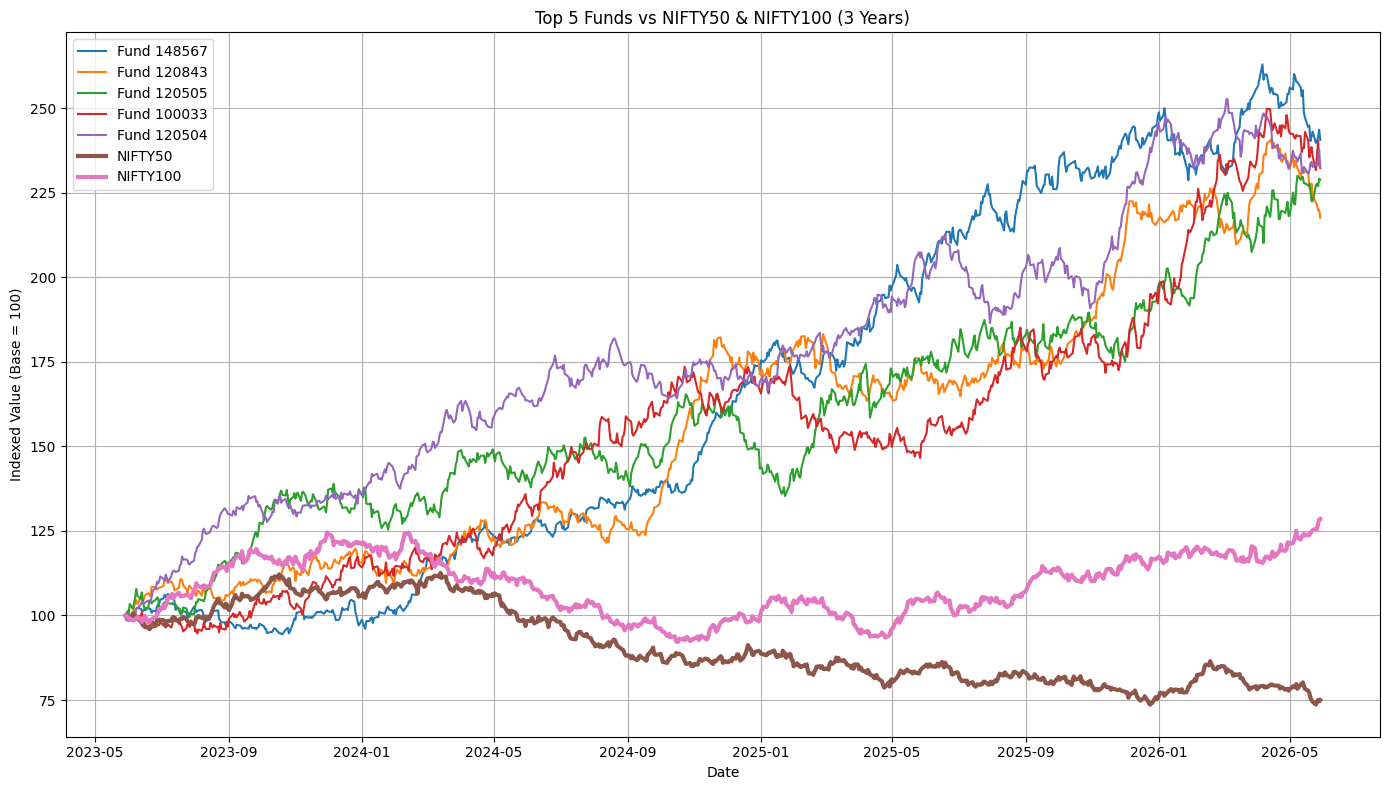

In [176]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

for code in top5_funds:

    temp = nav_3y[
        nav_3y["amfi_code"] == code
    ].copy()

    temp = temp.sort_values("date")

    temp["Indexed_Value"] = (
        temp["nav"]
        / temp["nav"].iloc[0]
    ) * 100

    plt.plot(
        temp["date"],
        temp["Indexed_Value"],
        label=f"Fund {code}"
    )

# NIFTY50

plt.plot(
    nifty50["date"],
    nifty50["Indexed_Value"],
    linewidth=3,
    label="NIFTY50"
)

# NIFTY100

plt.plot(
    nifty100["date"],
    nifty100["Indexed_Value"],
    linewidth=3,
    label="NIFTY100"
)

plt.title(
    "Top 5 Funds vs NIFTY50 & NIFTY100 (3 Years)"
)

plt.xlabel("Date")
plt.ylabel("Indexed Value (Base = 100)")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "benchmark_comparison.png",
    dpi=300
)

plt.show()

Compute Benchmark Returns

In [177]:
nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100_returns = nifty100[
    ["date", "benchmark_return"]
].dropna()

Tracking Error Calculation

In [178]:
tracking_error_list = []

for code in top5_funds:

    fund = returns[
        returns["amfi_code"] == code
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund,
        nifty100_returns,
        on="date",
        how="inner"
    ).dropna()

    tracking_error = (
        (
            merged["daily_return"]
            - merged["benchmark_return"]
        ).std()
    ) * np.sqrt(252)

    tracking_error_list.append([
        code,
        tracking_error
    ])

Tracking Error Table

In [179]:
tracking_error_df = pd.DataFrame(
    tracking_error_list,
    columns=[
        "amfi_code",
        "Tracking_Error"
    ]
)

tracking_error_df = tracking_error_df.sort_values(
    "Tracking_Error"
)

print(tracking_error_df)

   amfi_code  Tracking_Error
4     120504        0.187299
0     148567        0.187974
1     120843        0.206540
3     100033        0.224976
2     120505        0.232661


Saving Benchmark_comparision.csv

In [181]:
tracking_error_df.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)

print("tracking_error.csv saved")

tracking_error.csv saved
